### To build Deep Learning Model Pipeline we 2 libraries:

1. Tensorflow - very old library-> need to write every function manually -> Lengthy codes
2. Keras 2.0- is built on top of tensorflow. Dependent on Tensorflow
3. Keras 3.0 - is independent of Tensorflow

In [1]:
# import tensorflow as tf #tensorflow v.1

In [2]:
# from tensorflow import keras # keras 2.0

In [3]:
#import keras # keras 3.0

### =====================================================================

# 1.Installing Keras

In [4]:
!pip install keras

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.4 MB 3.7 MB/s eta 0:00:01
   ---------------------------------- ----- 2.1/2.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/566.7 kB ? eta -:--:--
   ---------------------------------------- 566.7/566.7 kB 3.6 MB/s  0:00:00

   -------- ------------------------------- 1/5 [optree]
   -------- ------------------------------- 1/5 [optree]
   -------- ------------------------------- 1/5 [optree]
   -------- ------------------------------- 1/5 [optree]
   ---------------- ----------------------- 2/5 [ml-dtypes]
   ------------------------ --------------- 3/5 [absl-py]
   ------------------------ --------------- 3/5 [absl-py]
   ---

In [5]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 3.7 MB/s eta 0:01:36
   ---------------------------------------- 1.8/351.2 MB 4.0 MB/s eta 0:01:28
   ---------------------------------------- 2.6/351.2 MB 4.1 MB/s eta 0:01:26
   ---------------------------------------- 3.7/351.2 MB 4.1 MB/s eta 0:01:26
    --------------------------------------- 4.5/351.2 MB 4.2 MB/s eta 0:01:24
    --------------------------------------- 5.2/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 6.0/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 7.1/351.2 MB 4.0 MB/s eta 0:01:26
    --------------------------------------- 8.1/351.2 MB 4.2 MB/s eta 0:01:23
   - -------------------------------------- 9.4/351.2 MB 4.3 MB/s eta 0:01:21


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


# =====================================================================

# Let's build our 1st Artificial Neural network(ANN)

# 1.Import necessary libraries

In [7]:
import keras
import matplotlib.pyplot as plt 
import pandas as pd

# 2.Data Collection

In [9]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 3.Data Understanding

In [11]:
x_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [13]:
x_test.shape,y_test.shape

((10000, 28, 28), (10000,))

In [15]:
assert x_train.shape == (60000, 28, 28) #assert is the check geven condition True (shape --> (60000,28,28) let's check 28,28 is real or fack
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

### 3.1 Let's see how one image looks like

In [18]:
pd.set_option('display.max_columns', 29)

In [20]:
pd.DataFrame(x_train[10000]) #num range (0-255)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0,0,0,0,0,0,0


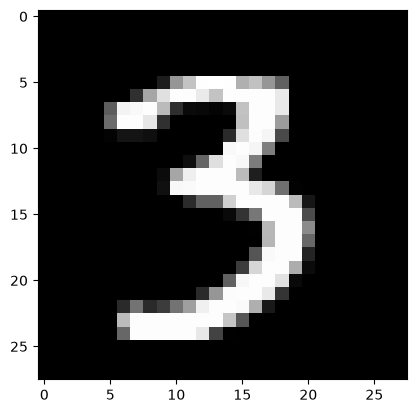

In [22]:
plt.imshow(x_train[10000],cmap='gray')

# 4.Data Preparation

### let's Normalize this for faster proessing

In [23]:
x_train.min(),x_train.max()

(np.uint8(0), np.uint8(255))

In [24]:
x_test.min(),x_test.max()

(np.uint8(0), np.uint8(255))

In [26]:
x_train = x_train/255.0
x_test  = x_test/255.0

In [27]:
x_train.min(),x_train.max()

(np.float64(0.0), np.float64(1.0))

In [28]:
x_test.min(),x_test.max()

(np.float64(0.0), np.float64(1.0))

# 5.Model Building

In [30]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [39]:
model = Sequential()
model.add(layer= Flatten()) #This is creating a input layer(image size = 28*28 --> 784)
model.add(Dense(units = 100,activation='relu'))#This is hinden layer
model.add(Dense(units = 100,activation='relu'))
model.add(Dense(units = 10,activation='softmax'))  #This is output layer  
model.summary()

# the above you only create a ANN Architecture 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Noe desaid the optimiser lose function that thinks

model.compile(optimizer='rmsprop',loss="sparse_categorical_crossentropy",metrics=["sparse_categorical_accuracy"])

###   MULTY CLASS CLASSIFICATION
# Defulte --> rmsprop
# Loss --> integet o/p so take sparse_categorical_crossentropy check the document
#Accuracy metrics = check accuracy for model (sparse_categorical_accuracy) use only list this is multy class so take this

# 6.Model Training || 7.Model testing || 8.Model Evakuation

In [41]:
model.fit(x=x_train,y=y_train,batch_size=32,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2492 - sparse_categorical_accuracy: 0.9261 - val_loss: 0.1331 - val_sparse_categorical_accuracy: 0.9585
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1107 - sparse_categorical_accuracy: 0.9664 - val_loss: 0.1147 - val_sparse_categorical_accuracy: 0.9651
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0827 - sparse_categorical_accuracy: 0.9748 - val_loss: 0.0877 - val_sparse_categorical_accuracy: 0.9754
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0667 - sparse_categorical_accuracy: 0.9805 - val_loss: 0.0791 - val_sparse_categorical_accuracy: 0.9766
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0562 - sparse_categorical_accuracy: 0.9840 - val_loss: 0.0865 - val_sparse_categorical_accuracy: 0.9762
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0492 - sparse_categorical_accuracy: 0.9858 - val_loss: 0.0850 - val_sparse_categorical_accuracy:

In [42]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (32, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (32, 100)                   │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (32, 10)                    │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 179,222 (700.09 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,612 (350.05 KB)

# 9.Manual Model Prediction

In [43]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [44]:
y_test[500]

np.uint8(3)

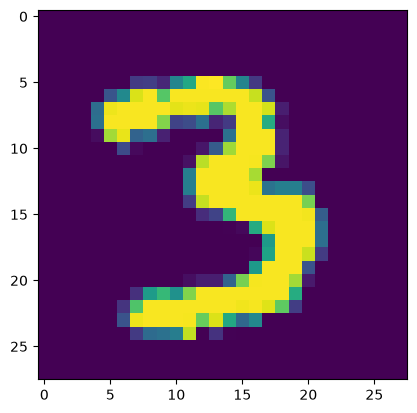

In [47]:
plt.imshow(x_test[500])

In [50]:
import numpy as np
np.argmax(y_pred[500]) #A max value is get at output that value can take

np.int64(3)

## =======================================================

# FINAL POINT : Let's Test for outsaid new data

### step 1:Let's take out the model intelligece file

In [52]:
model.save("digits_intel.h5") # h5 is interstial level use case of file name

### step 2:Image Load

In [65]:
from PIL import Image #python imaging libraries this is take image all file 
img_path = r"C:\Users\Tamilarasan\OneDrive\Desktop\ProItPridge\Deep Learning\08 Chaoter_7 MINIST Digits Classification\Screenshot 2026-09-23 204458.png"
image = Image.open(img_path) #this is open a image 
image = image.convert(mode='L') #This is change the image color
image = image.resize(size=(28,28))
image

In [64]:
image.size

(28, 28)

In [74]:
from PIL import Image #python imaging libraries this is take image all file 
img_path = r"C:\Users\Tamilarasan\OneDrive\Desktop\ProItPridge\Deep Learning\08 Chaoter_7 MINIST Digits Classification\Screenshot 2026-09-23 204458.png"
image = Image.open(img_path).convert(mode='L').resize(size=(28,28))
image = np.array(image) #this is only model understand the array value not image
image

array([[ 34,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,
         21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,  21,
         21,  22],
       [ 10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [ 10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   1,   9,  11,   1,   0,   0,   0,   0,   0,
          0,   0],
       [  9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   7, 106, 124,   7,   2,   1,   0,   0,   0,
          0,   0],
       [  9,   0,   2,   9,  19,   9,   0,   1,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  31, 172, 202,  60,   0,   1,   0,   0,   0,
          0,   0],
       [  

In [78]:
predict_image(image)

(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[1.6616512e-32, 5.5634258e-21, 1.1871421e-19, 1.6261861e-21,
        1.0000000e+00, 6.0132630e-24, 2.6806455e-22, 3.0837379e-19,
        1.2554359e-21, 2.6326402e-15]], dtype=float32)

### Step 3: Le's do the Prediction

In [68]:
from keras.models import load_model
digite_brain = load_model("digits_intel.h5")

In [83]:
def predict_image(image):
    image = image/255.0
    image = np.expand_dims(a= image,axis=0) #this is you tell model this is gray inage (1,28,28) (1--> color or gray)
    print(image.shape)
    prediction = digite_brain.predict(image)
    return np.argmax(prediction)

In [84]:
predict_image(image) # this error beacouse direct you put image do the prediction model not able to predict because only perdict a array

(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


np.int64(4)

# THE END !!!!